# Finding the CZ phase — and validating its effective theory

This notebook has two parts.

**Part A — the full seven-level gate (§1–§3).** Build the digital–analog CZ pulse and
drive the *full* seven-level Rb-87 ladder
$\{|0\rangle,|1\rangle,|e_1\rangle,|e_2\rangle,|e_3\rangle,|r\rangle,|r'\rangle\}$ for two
interacting atoms, then read off the gate's single-qubit and entangling (ZZ) phases
(§2), the level populations (§3), and the coherent loss budget. This exact simulation
is the **ground truth**.

**Part B — validating the reduction (§4).** The `tech` note models the gate with a much
simpler *effective three-level* theory on $\{|0\rangle,|1\rangle,|r\rangle\}$, obtained by
adiabatically eliminating the far-detuned $6P$ manifold (Schrieffer–Wolff). §4 puts that
theory on trial against the seven-level ground truth, in four steps:

1. **§4.1 — reconstruct.** Rebuild the seven-level propagator from the library's own
   blocks and confirm it reproduces Part A (so the comparison is apples-to-apples).
2. **§4.2 — eliminate.** Do the second-order SW projection $H_7\!\to\!H_{\rm eff}$ and
   evolve the effective two-atom model with the *identical* waveform and interaction.
3. **§4.3 — compare.** Check the gauge-invariant observables: single-qubit phase, ZZ
   phase, and the Rydberg-population trajectories.
4. **§4.4 — cross-check.** Compare the theorem's *closed-form* coefficients
   ($D_0,D_1,D_r,K_{1r},K_{01}$) against the numeric elimination.

**The payoff (§4.5):** the $\{0,1,r\}$ picture reproduces the full dynamics — populations
to $10^{-3}$, single-qubit phase to $3\times10^{-3}$ rad, ZZ to $\sim$2% (the expected
next-order Stark correction), and the analytic coefficients to $0.1\%$.

In [1]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate.lattice import Register
from ryd_gate.protocols.gate_cz import DoubleARPProtocol
from ryd_gate.core.operators import build_occ_operator

MHz = 2 * np.pi * 1e6
us = 1e-6
wrap = lambda a: float(np.angle(np.exp(1j * a)))     # wrap to (-pi, pi]
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})



BLAS/OpenMP threads pinned to 1


## 1. The pulse and the 7-level driver

Our digital–analog pulse uses a quintic-smoothstep Rabi envelope and a round-trip Rydberg detuning sweep. With gate time $T$ and normalized time $s=t/T$,

$$
\Omega_R(t)=\Omega_{\mathrm{eff}}\,\mathrm{env}(t), \qquad
\Delta_R(t)=-\delta_{\mathrm{amp}}\cos(2\pi s).
$$

The envelope $\mathrm{env}(s)$ rises and falls on the edges $s\in[0,\tau]$ and $s\in[1-\tau,1]$ via the quintic smoothstep
$h(u)=10u^3-15u^4+6u^5$, and is flat on the plateau ($\tau=0.09$ here).

The hardware caps the detuning sweep at $\delta_{\mathrm{amp}}=2\pi\times 20\,\mathrm{MHz}$. For the `our` parameter set,
$\Omega_{\mathrm{eff}}=\Omega_{420}\Omega_{1013}/(2\Delta_e)\equiv\omega_{\mathrm{rabi,eff}}$ (numerically $\Omega_{\mathrm{eff}}/2\pi\approx 5\,\mathrm{MHz}$).

The seven-level model is driven by a **three-line subclass of `DoubleARPProtocol`** (only the waveform is overridden). The inherited machinery maps $(\Omega_R,\Delta_R)$ onto the `drive_420` (+ conjugate) channels and exposes the second-order Stark parameters from the same local blocks used in the simulation. With `compensate_stark=False`, the seven-level run uses the *bare* chirp and Stark shifts build up dynamically.

In [ ]:
SPACING_UM = 3.0
D_AMP = 20.0 * MHz       # hardware-capped detuning sweep half-amplitude
T = 1.0e-6               # gate time (long enough for an adiabatic single-atom return)
N_STEPS = 3000          # piecewise-constant steps (converged: leakage ~1e-5 at T=6us)
N_EVAL = 301
RAMP = 0.15              # smoothstep rise/fall fraction
OPTICS_LOSS = 0.9        # 90% loss of power

labels = ["00", "01", "10", "11"]
cfgs = [list(s) for s in labels]            # per-atom label-lists -> one batched rg.simulate call
n0 = {"00": 2, "01": 1, "10": 1, "11": 0}   # number of |0> atoms in s
n1 = {"00": 0, "01": 1, "10": 1, "11": 2}   # number of |1> atoms in s

def smooth_env(t, t_gate):
    s = float(np.clip(t / t_gate, 0.0, 1.0))
    q = lambda u: (lambda v: 10*v**3 - 15*v**4 + 6*v**5)(np.clip(u, 0, 1))
    if s < RAMP: return float(q(s / RAMP))
    if s > 1 - RAMP: return float(q((1 - s) / RAMP))
    return 1.0

class SweepARP(DoubleARPProtocol):
    # DoubleARP 7-level machinery with OUR digital-analog round-trip waveform
    def envelope(self, t):
        return smooth_env(float(t), self.t_gate)
    def detuning(self, t, params=None):
        s = float(np.clip(float(t) / self.t_gate, 0.0, 1.0))
        return float(-self.delta_max * np.cos(2.0 * np.pi * s))

from ryd_gate.physics import our_laser_rabis

beam_area_um2 = 7 * 20 * SPACING_UM
omega_420, omega_1013 = our_laser_rabis(
    p420_w=6.41*(1 - OPTICS_LOSS),           # 420 nm 功率 (W)
    p1013_w=100.0*(1 - OPTICS_LOSS),         # 1013 nm 功率 (W)
    beam_area=beam_area_um2,  # 光斑面积 (μm²)
    ryd_level=70,
)
print(f"omega_420/2pi = {omega_420/MHz:.3f} MHz, omega_1013/2pi = {omega_1013/MHz:.3f} MHz")
# The 420/1013 drive: laser intensities/detuning now live on the protocol.
proto = SweepARP(
    omega_max=None, delta_max=D_AMP, t_gate=T, n_steps=N_STEPS,
    compensate_stark=True, stark_compensation_sign=1,
    Delta_Hz=40.1e9,
    rabi_420_Hz=omega_420 / (2 * np.pi),
    rabi_1013_Hz=omega_1013 / (2 * np.pi),
)
sys7 = (
    rg.RydbergSystem
    .set_atom_level("rb87_7", param_set="our", blackmanflag=False,
                    detuning_sign=1)
    .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
    .set_protocol(proto)
)
proto.plot(sys7)
RABI_EFF = sys7.meta("rabi_eff")
print(f"dim={sys7.dim}  rabi_eff/2pi = {RABI_EFF/MHz:.3f} MHz  V_nn/2pi = {sys7.metadata['interaction_pairs'][0][2]/MHz:.1f} MHz")

## 2. Full 7-level reference phases

Evolve all four computational basis states (one batched `rg.simulate` call, sharing propagators; auto-routed
to the dense backend) and read `phi_full(s)=arg<s|psi(T)>`. A clean (low-leakage) return is required for
the phase to be well defined.

In [3]:
t_eval = np.linspace(0.0, T, N_EVAL)
occ7r = build_occ_operator(5, 7)   # total |r> population (level index 5)
states7 = [sys7.product_state(s) for s in labels]
results7 = rg.simulate(sys7, psi0=cfgs, t_eval=t_eval)
phi_full, nr7 = {}, {}
print(" s  | return prob | leakage  | phi_full")
for j, s in enumerate(labels):
    psi_f = results7[j].psi_final
    ov = np.vdot(states7[j], psi_f)
    leak = 1.0 - sum(abs(np.vdot(states7[k], psi_f))**2 for k in range(4))
    phi_full[s] = float(np.angle(ov))
    nr7[s] = np.array([np.real(np.vdot(p, occ7r @ p)) for p in results7[j].states])
    print(f" {s} |  {abs(ov)**2:.6f}  | {leak:.2e} | {phi_full[s]:+.5f}")

print("ZZ phase: ", wrap(phi_full["11"] - phi_full["01"] - phi_full["10"] + phi_full["00"]))

 s  | return prob | leakage  | phi_full
 00 |  1.000000  | 2.22e-16 | -2.06837
 01 |  0.999955  | 3.99e-05 | -1.78330
 10 |  0.999955  | 3.99e-05 | -1.78330
 11 |  0.999976  | 2.40e-05 | +1.89745
ZZ phase:  -2.8875015711709073


## 3. Level population evolution

For each computational basis initial state, plot per-atom occupation in $|0\rangle$, $|1\rangle$, intermediate ($e_1+e_2+e_3$), target Rydberg $|r\rangle$, and garbage Rydberg $|r_{\mathrm{garb}}\rangle$ (same grouping as `01_cz_gate.ipynb`).

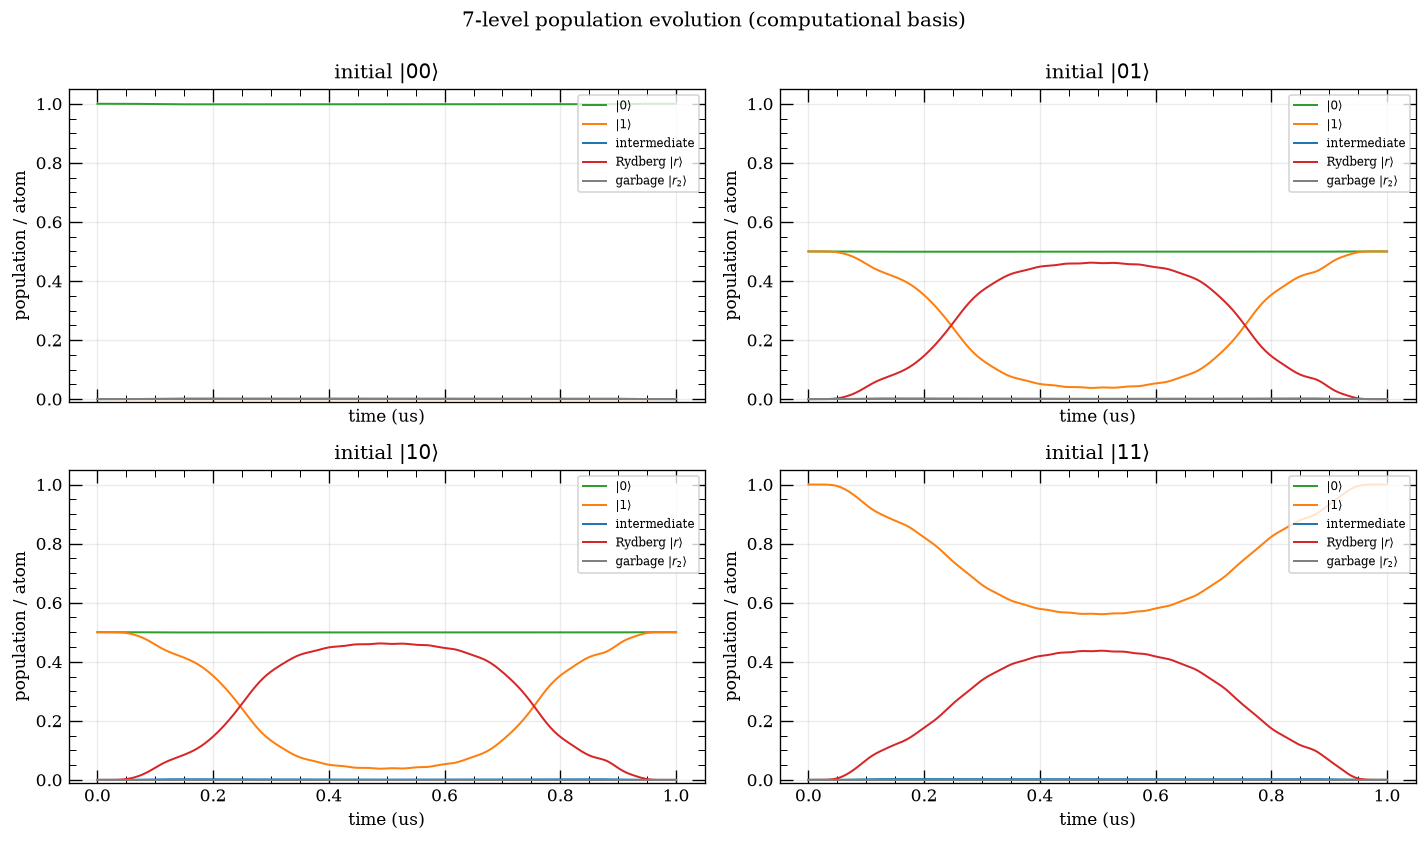

In [5]:
level_ops = {
    r"$|0\rangle$": build_occ_operator(0, 7),
    r"$|1\rangle$": build_occ_operator(1, 7),
    "intermediate": sum(build_occ_operator(i, 7) for i in (2, 3, 4)),
    r"Rydberg $|r\rangle$": build_occ_operator(5, 7),
    r"garbage $|r_2\rangle$": build_occ_operator(6, 7),
}
colors = {
    r"$|0\rangle$": "tab:green",
    r"$|1\rangle$": "tab:orange",
    "intermediate": "tab:blue",
    r"Rydberg $|r\rangle$": "tab:red",
    r"garbage $|r_2\rangle$": "gray",
}

time_us = results7[0].times / us

def pop_per_atom(psi_list, op):
    return np.array([np.real(np.vdot(p, op @ p)) for p in psi_list]) / 2.0

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (j, s) in zip(axes.ravel(), enumerate(labels)):
    for name, op in level_ops.items():
        ax.plot(time_us, pop_per_atom(results7[j].states, op), lw=1.2, color=colors[name], label=name)
    ax.set_title(f"initial $|{s}\\rangle$")
    ax.set_ylim(-0.01, 1.05)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population / atom")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("7-level population evolution (computational basis)", y=0.995)
fig.tight_layout()
plt.show()

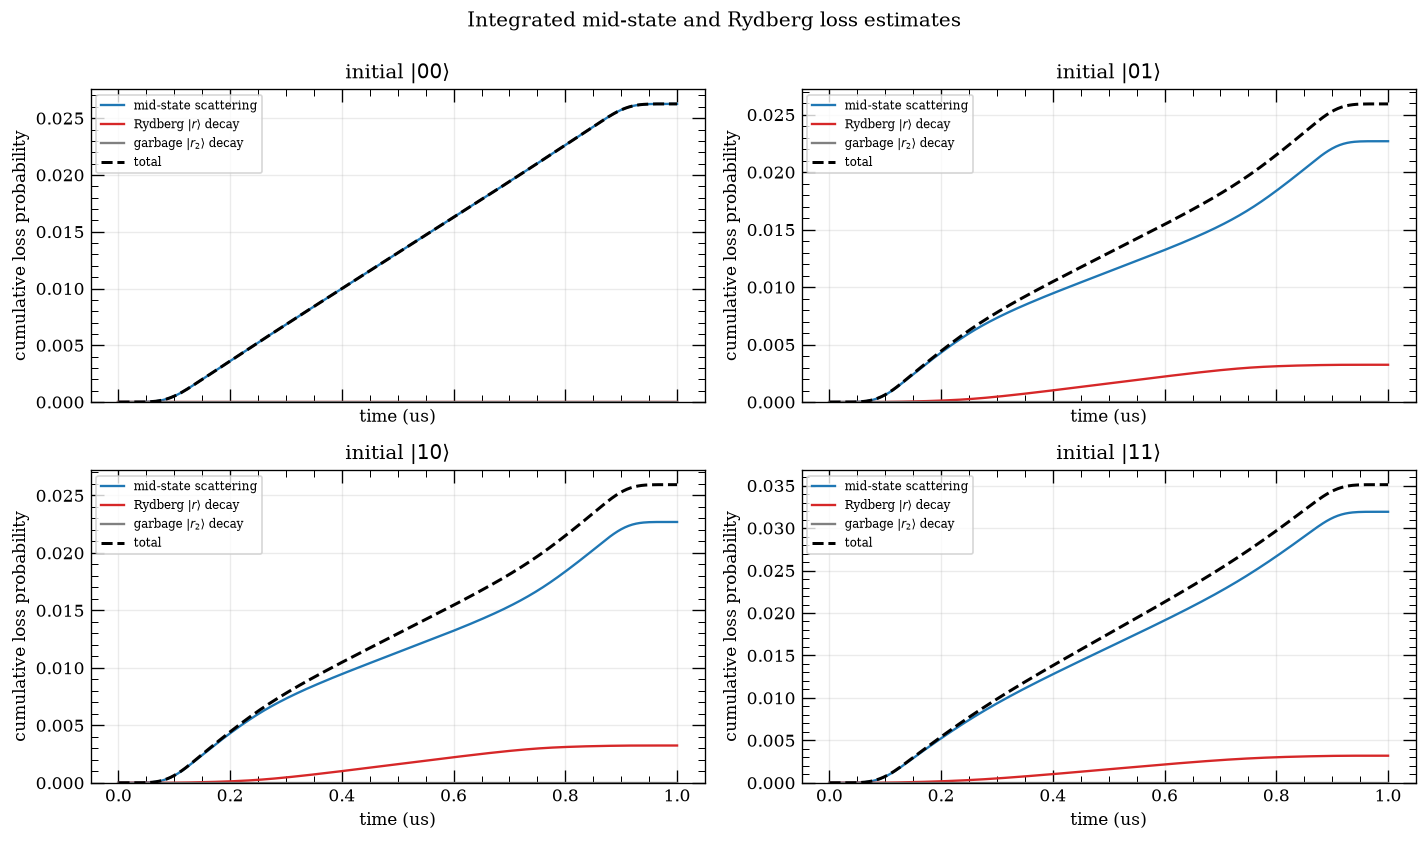

Gamma_e = 9.033424e+06 s^-1
Gamma_r = 6.598482e+03 s^-1
 s  | p_mid      | p_ryd      | p_r_garb   | p_total
 00 | 2.626e-02 | 9.045e-09 | 6.239e-11 | 2.626e-02
 01 | 2.269e-02 | 3.247e-03 | 1.832e-11 | 2.594e-02
 10 | 2.269e-02 | 3.247e-03 | 1.832e-11 | 2.594e-02
 11 | 3.192e-02 | 3.195e-03 | 1.151e-11 | 3.511e-02


In [6]:
# Integrated loss estimates from the coherent 7-level trajectories.
# These are first-order event probabilities, not a non-Hermitian norm loss.

Gamma_e = float(sys7.meta("mid_state_decay_rate"))
Gamma_r = float(sys7.meta("ryd_state_decay_rate"))
Gamma_r_garb = float(sys7.meta("ryd_garb_decay_rate", Gamma_r))

occ7e = level_ops["intermediate"]
occ7r = level_ops[r"Rydberg $|r\rangle$"]
occ7rg = level_ops[r"garbage $|r_2\rangle$"]

def expect_series(psi_list, op):
    return np.asarray([np.real(np.vdot(p, op @ p)) for p in psi_list], dtype=float)

def cumulative_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y, dtype=float)
    if y.size > 1:
        out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

loss_curves7 = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (j, s) in zip(axes.ravel(), enumerate(labels)):
    t = np.asarray(results7[j].times, dtype=float)
    ne = expect_series(results7[j].states, occ7e)
    nr = expect_series(results7[j].states, occ7r)
    nrg = expect_series(results7[j].states, occ7rg)

    p_mid = cumulative_trapezoid(Gamma_e * ne, t)
    p_ryd = cumulative_trapezoid(Gamma_r * nr, t)
    p_r_garb = cumulative_trapezoid(Gamma_r_garb * nrg, t)
    p_total = p_mid + p_ryd + p_r_garb
    loss_curves7[s] = {
        "mid": p_mid,
        "ryd": p_ryd,
        "r_garb": p_r_garb,
        "total": p_total,
        "ne": ne,
        "nr": nr,
        "nrg": nrg,
    }

    ax.plot(t / us, p_mid, lw=1.4, color="tab:blue", label="mid-state scattering")
    ax.plot(t / us, p_ryd, lw=1.4, color="tab:red", label=r"Rydberg $|r\rangle$ decay")
    ax.plot(t / us, p_r_garb, lw=1.4, color="gray", label=r"garbage $|r_2\rangle$ decay")
    ax.plot(t / us, p_total, lw=1.8, color="black", ls="--", label="total")
    ax.set_title(f"initial $|{s}\\rangle$")
    ax.set_xlabel("time (us)")
    ax.set_ylabel("cumulative loss probability")
    ax.set_ylim(bottom=0.0)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Integrated mid-state and Rydberg loss estimates", y=0.995)
fig.tight_layout()
plt.show()

print(f"Gamma_e = {Gamma_e:.6e} s^-1")
print(f"Gamma_r = {Gamma_r:.6e} s^-1")
print(" s  | p_mid      | p_ryd      | p_r_garb   | p_total")
for s in labels:
    p_mid = loss_curves7[s]["mid"][-1]
    p_ryd = loss_curves7[s]["ryd"][-1]
    p_r_garb = loss_curves7[s]["r_garb"][-1]
    p_total = loss_curves7[s]["total"][-1]
    print(f" {s} | {p_mid:.3e} | {p_ryd:.3e} | {p_r_garb:.3e} | {p_total:.3e}")

In [17]:
# 2x2 lattice: check what the current 7-level implementation supports,
# then optionally run an exact_dense population diagnostic.

from ryd_gate.core.level_structures import level_structure

geom_2x2 = Register.rectangle(2, 2, spacing_um=SPACING_UM)
sys7_2x2 = (
    rg.RydbergSystem
    .set_atom_level("rb87_7", param_set="our", blackmanflag=False, detuning_sign=1)
    .set_atom_geom(geom_2x2)
    .set_protocol(proto)
)

spec_7 = level_structure("rb87_7")
print(f"2x2 rb87_7: N={sys7_2x2.N}, local_dim={sys7_2x2.basis.local_dim}, dim={sys7_2x2.dim}")
print("backend support matrix:", {name: spec_7.supports_backend(name) for name in ("exact", "mps", "peps")})
print(f"rabi_eff/2pi = {sys7_2x2.meta('rabi_eff') / MHz:.3f} MHz")
print("interaction pairs (i, j, V/2pi MHz):")
for i, j, vij in sys7_2x2.metadata["interaction_pairs"]:
    print(f"  {i}-{j}: {vij / MHz:.3f}")

# build_occ_operator(index, 7) above is a two-atom 49x49 operator.
# For 2x2, use the registered many-body observables on sys7_2x2 instead.
population_channels_2x2 = {
    r"$|0\rangle$": ("sum_n_0", "tab:green"),
    r"$|1\rangle$": ("sum_n_1", "tab:orange"),
    "intermediate": (("sum_n_e1", "sum_n_e2", "sum_n_e3"), "tab:blue"),
    r"Rydberg $|r\rangle$": ("sum_n_r", "tab:red"),
    r"garbage $|r_2\rangle$": ("sum_n_r_garb", "gray"),
}

def pop_per_atom_2x2(system, psi_list, obs_names):
    if isinstance(obs_names, str):
        obs_names = (obs_names,)
    return np.asarray([
        sum(system.expectation(obs_name, psi) for obs_name in obs_names) / system.N
        for psi in psi_list
    ], dtype=float)

# exact_dense on rb87_7 2x2 has dim = 2401 and forms a dense expm at each step.
# Keep this off by default; enable it only for a small diagnostic run.
DENSE_2X2_N_STEPS = 3000
DENSE_2X2_N_EVAL = 300
dense_labels_2x2 = ["0000", "0001", "0011", "1111"]

dense_proto_2x2 = SweepARP(
    omega_max=None,
    delta_max=D_AMP,
    t_gate=T,
    n_steps=DENSE_2X2_N_STEPS,
    compensate_stark=True,
    stark_compensation_sign=1,
)
dense_system_2x2 = sys7_2x2.with_protocol(dense_proto_2x2)
dense_t_eval_2x2 = np.linspace(0.0, T, DENSE_2X2_N_EVAL)
dense_cfgs_2x2 = [list(s) for s in dense_labels_2x2]

dense_results_2x2 = rg.simulate(
    dense_system_2x2,
    psi0=dense_cfgs_2x2,
    backend="exact_dense",
    backend_options={"n_steps": DENSE_2X2_N_STEPS},
    t_eval=dense_t_eval_2x2,
)

time_us_2x2 = dense_results_2x2[0].times / us
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (j, s) in zip(axes.ravel(), enumerate(dense_labels_2x2)):
    for name, (obs_names, color) in population_channels_2x2.items():
        ax.plot(
            time_us_2x2,
            pop_per_atom_2x2(dense_system_2x2, dense_results_2x2[j].states, obs_names),
            lw=1.2,
            color=color,
            label=name,
        )
    ax.set_title(f"initial $|{s}\rangle$")
    ax.set_ylim(-0.01, 1.05)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population / atom")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("2x2 rb87_7 exact_dense population diagnostic", y=0.995)
fig.tight_layout()
plt.show()


2x2 rb87_7: N=4, local_dim=7, dim=2401
backend support matrix: {'exact': True, 'mps': False, 'peps': False}
rabi_eff/2pi = 13.082 MHz
interaction pairs (i, j, V/2pi MHz):
  0-1: 1198.903
  0-2: 1198.903
  0-3: 149.863
  1-2: 149.863
  1-3: 1198.903
  2-3: 1198.903


KeyboardInterrupt: 

## 4. Verifying the effective $\{0,1,r\}$ theory

Sections 1–3 simulated the **full seven-level** Rb-87 ladder $\{|0\rangle,|1\rangle,|e_{1,2,3}\rangle,|r\rangle,|r'\rangle\}$.
The `tech` note derives, by a time-dependent Schrieffer–Wolff (SW) transformation, an **effective three-level**
Hamiltonian on $\{|0\rangle,|1\rangle,|r\rangle\}$ obtained by adiabatically eliminating the far-detuned
$6P_{3/2}$ manifold (and the 56-GHz-detuned garbage state $|r'\rangle$). Here we test that theory against the
exact seven-level dynamics, for **two atoms with the Rydberg interaction** $V\,n_r^i n_r^j$ switched on — exactly
the gate task of Section 2.

**Strategy**

1. **Reconstruct** the seven-level propagator $H_7(t)$ from the *same* single-atom blocks the library uses, and
   confirm it reproduces `phi_full` (validates the comparison machinery and our drive extraction).
2. **Eliminate** the $6P$ manifold by a second-order (Löwdin / SW) projection $H_7(t)\to H_{\rm eff}(t)$ on
   $\{|0\rangle,|1\rangle,|r\rangle\}$, evolve the two-atom effective model with the identical waveform and
   interaction, and compare phases and populations.
3. **Cross-check** the numerically projected matrix elements against the *closed-form* coefficients
   $D_0,D_1,D_r,K_{1r},K_{01}$ of the theorem (the Clebsch–Gordan sums $\tfrac43,\tfrac23,\dots$).

All parameters ($\Delta_e,\ \Omega_{420},\ \Omega_{1013},\ \varepsilon_0,\ \eta_F,\ V$) are read straight from the
bound `sys7`, so the effective model and the seven-level model share identical numbers.

### 4.1 Reconstruct the full seven-level propagator

The library evolves
$H_7(t)=H_{\rm const}+(H_{1013}+H_{1013}^\dagger)+c(t)\,h_{420}+c^*(t)\,h_{420}^\dagger$,
where the only time dependence is the complex 420-nm drive coefficient $c(t)=\mathrm{env}(t)\,e^{-i\phi(t)}$
(the detuning sweep is carried by the chirp $\dot\phi$, and the 1013-nm coupling is static). We rebuild that
operator from the registered blocks and propagate the two-atom product states with the same midpoint
piecewise-constant scheme as `DenseExpmBackend`. The reconstructed phases must match `phi_full` to machine
precision — confirming that everything downstream compares like with like.

In [ ]:
from scipy.linalg import expm

# Single-atom 7x7 blocks, exactly as the library assembles them.
Hc_7   = np.asarray(sys7.blocks.get("H_const").matrix)      # diagonal level energies
h420   = np.asarray(sys7.blocks.get("drive_420").matrix)    # 420 nm |e><0|, |e><1| legs
h1013  = np.asarray(sys7.blocks.get("H_1013").matrix)       # static 1013 nm |r><e|, |r'><e|
Hstat7 = Hc_7 + h1013 + h1013.conj().T                      # time-independent part
V_nn   = float(sys7.metadata["interaction_pairs"][0][2])    # nearest-neighbour Rydberg V
_pp    = proto.unpack_params([], sys7)                       # protocol params (builds the phase table)

def drive_coeff(t):
    """Complex 420 nm drive coefficient env(t)*exp(-i phi(t)) used by the library."""
    return proto.get_drive_coefficients(float(t), _pp)["drive_420"]

def H7_local(t):
    c = drive_coeff(t)
    return Hstat7 + c * h420 + np.conj(c) * h420.conj().T

ryd7 = np.zeros((7, 7)); ryd7[5, 5] = 1.0; ryd7[6, 6] = 1.0   # |r> (5) + garbage |r'> (6)
LOC_IDX = {"0": 0, "1": 1}                                    # computational label -> local index

def evolve_two_atom(Hloc_fn, dim, ryd_proj, Vint, n_steps=N_STEPS, n_eval=N_EVAL):
    """Midpoint piecewise-constant propagation of the 4 product states (mirrors DenseExpmBackend)."""
    I = np.eye(dim)
    Hint = Vint * np.kron(ryd_proj, ryd_proj)
    nr_op = np.kron(ryd_proj, I) + np.kron(I, ryd_proj)
    dt = T / n_steps
    rec = set(np.linspace(0, n_steps, n_eval).round().astype(int).tolist())
    psis, traj = {}, {s: [] for s in labels}
    for s in labels:
        psis[s] = np.kron(np.eye(dim)[LOC_IDX[s[0]]], np.eye(dim)[LOC_IDX[s[1]]]).astype(complex)
    if 0 in rec:
        for s in labels: traj[s].append(psis[s].copy())
    for k in range(n_steps):
        Hl = Hloc_fn((k + 0.5) * dt)
        U = expm(-1j * dt * (np.kron(Hl, I) + np.kron(I, Hl) + Hint))
        for s in labels:
            psis[s] = U @ psis[s]
        if (k + 1) in rec:
            for s in labels: traj[s].append(psis[s].copy())
    return psis, {s: np.array(traj[s]) for s in labels}, nr_op

def return_phase(psis, dim):
    out = {}
    for s in labels:
        ket = np.kron(np.eye(dim)[LOC_IDX[s[0]]], np.eye(dim)[LOC_IDX[s[1]]])
        out[s] = float(np.angle(np.vdot(ket, psis[s])))
    return out

zz = lambda p: wrap(p["11"] - p["01"] - p["10"] + p["00"])

psis7, traj7, nr7op = evolve_two_atom(H7_local, 7, ryd7, V_nn)
phi_recon = return_phase(psis7, 7)
print("machinery check  -  reconstructed 7-level vs library rg.simulate")
print(f"  ZZ   library = {zz(phi_full):+.6f}    reconstruction = {zz(phi_recon):+.6f}"
      f"    |diff| = {abs(wrap(zz(phi_recon) - zz(phi_full))):.2e}")
print(f"  max |phi_recon - phi_full| over the 4 states = "
      f"{max(abs(wrap(phi_recon[s] - phi_full[s])) for s in labels):.2e}")

### 4.2 Schrieffer–Wolff elimination of the $6P$ manifold

Splitting the levels into the kept block $P=\{|0\rangle,|1\rangle,|r\rangle\}$ and the eliminated block
$Q=\{|e_1\rangle,|e_2\rangle,|e_3\rangle\}$, the second-order effective Hamiltonian is the standard symmetric
(Löwdin) form

$$
\big(H_{\rm eff}\big)_{ab}=H_{ab}+\frac12\sum_{q\in Q}H_{aq}H_{qb}\left[\frac{1}{E_a-E_q}+\frac{1}{E_b-E_q}\right],
\qquad a,b\in P,
$$

with the bare level energies $E$ taken from $H_{\rm const}$. This *is* the construction of Theorem 1 — the
$D$ light shifts ($a=b$) and the symmetrized $K$ couplings ($a\neq b$). The garbage state $|r'\rangle$ couples to
$P$ only *through* $Q$ and sits 56 GHz away, so it drops out at this order (and stays unpopulated in the
seven-level run). We then evolve the two-atom effective model
$H_{\rm eff}\otimes I + I\otimes H_{\rm eff} + V\,n_r\otimes n_r$ with the identical drive.

In [ ]:
P_IDX = [0, 1, 5]; Q_IDX = [2, 3, 4]          # keep {0,1,r}; eliminate {e1,e2,e3}
E0 = np.real(np.diag(Hc_7))                    # bare energies for the SW denominators

def H_eff_local(t):
    H = H7_local(t)
    M = H[np.ix_(P_IDX, P_IDX)].astype(complex).copy()
    for ai, a in enumerate(P_IDX):
        for bi, b in enumerate(P_IDX):
            corr = 0j
            for q in Q_IDX:
                corr += H[a, q] * H[q, b] * 0.5 * (1 / (E0[a] - E0[q]) + 1 / (E0[b] - E0[q]))
            M[ai, bi] += corr
    return M

ryd_eff = np.zeros((3, 3)); ryd_eff[2, 2] = 1.0   # |r> = local index 2 in {0,1,r}
psis_e, traj_e, nr_eop = evolve_two_atom(H_eff_local, 3, ryd_eff, V_nn)
phi_eff = return_phase(psis_e, 3)
print(f"effective {{0,1,r}} ZZ phase = {zz(phi_eff):+.6f}   (7-level: {zz(phi_full):+.6f})")

### 4.3 Phases and populations: effective vs full

The physically meaningful, gauge-invariant outputs are the **single-qubit phase**
$\theta_1=\arg\langle01|\psi\rangle-\arg\langle00|\psi\rangle$ and the **two-qubit entangling phase**
$\Phi_{ZZ}=\phi_{11}-\phi_{01}-\phi_{10}+\phi_{00}$. (A phase common to $|0\rangle$ and $|1\rangle$ is an
unobservable global phase and cancels in both quantities.) We also overlay the Rydberg-population trajectories
$\langle n_r\rangle(t)$ summed over the two atoms.

In [ ]:
theta1 = lambda p: wrap(p["01"] - p["00"])     # single-qubit phase (flip one atom 0->1)

print("physical observables  -  effective {0,1,r} vs full 7-level")
print(f"  single-qubit phase  theta1 :  full = {theta1(phi_full):+.5f}   eff = {theta1(phi_eff):+.5f}"
      f"   |err| = {abs(wrap(theta1(phi_eff) - theta1(phi_full))):.2e} rad")
print(f"  entangling phase    ZZ     :  full = {zz(phi_full):+.5f}   eff = {zz(phi_eff):+.5f}"
      f"   |err| = {abs(wrap(zz(phi_eff) - zz(phi_full))):.2e} rad")

# Total |r> population trajectories (both atoms): 7-level (library) vs effective.
nr_full_t = {s: np.array([np.real(np.vdot(p, occ7r @ p)) for p in results7[j].states])
             for j, s in enumerate(labels)}
nr_eff_t  = {s: np.array([np.real(np.vdot(p, nr_eop @ p)) for p in traj_e[s]]) for s in labels}
print(f"  max |n_r(t) full - n_r(t) eff| over trajectory = "
      f"{max(np.max(np.abs(nr_full_t[s] - nr_eff_t[s])) for s in labels):.2e}")

tt = results7[0].times / us
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (j, s) in zip(axes.ravel(), enumerate(labels)):
    ax.plot(tt, nr_full_t[s], lw=1.8, color="tab:red", label=r"7-level $\langle n_r\rangle$")
    ax.plot(tt, nr_eff_t[s], lw=1.4, ls="--", color="black", label=r"effective $\langle n_r\rangle$")
    ax.set_title(f"initial $|{s}\\rangle$")
    ax.set_xlabel("time (us)"); ax.set_ylabel(r"$\langle n_r\rangle$ (both atoms)")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle(r"Total Rydberg population: full 7-level vs effective $\{0,1,r\}$", y=0.995)
fig.tight_layout()
plt.show()

### 4.4 Closed-form coefficients vs the numeric elimination

Finally we check the *analytic* coefficients of the theorem against the numerically projected $H_{\rm eff}$ at the
envelope plateau ($\mathrm{env}=1$). Using the Clebsch–Gordan sums
$\sum_F\Omega_{F1}^2=\sum_F\Omega_{F0}^2=\tfrac43\Omega_{420}^2$, $\sum_F\Omega_{Fr}^2=\Omega_{1013}^2$,
$\sum_F\Omega_{F1}\Omega_{Fr}=\Omega_{420}\Omega_{1013}$, $\sum_F\Omega_{F0}\Omega_{F1}=\tfrac23\Omega_{420}^2$:

$$
D_1=-\frac{4}{3}\frac{\Omega_{420}^2}{4\Delta_e},\quad
D_r=-\frac{\Omega_{1013}^2}{4\Delta_e},\quad
D_0=-\frac{4}{3}\frac{\Omega_{420}^2}{4(\Delta_e+\varepsilon_0)},\quad
|K_{1r}|=\frac{\Omega_{420}\Omega_{1013}}{4\Delta_e},\quad
K_{01}=\frac{2}{3}\Omega_{420}^2\!\left[\frac{1}{8\Delta_e}+\frac{1}{8(\Delta_e+\varepsilon_0)}\right].
$$

A ratio near $1$ confirms the angular-momentum bookkeeping; the residual $\sim10^{-3}$ is the hyperfine spread
$\eta_F$ of the $6P$ manifold that the closed forms approximate by a single $\Delta_e$.

In [ ]:
De   = sys7.meta("Delta"); R420 = sys7.meta("rabi_420"); R1013 = sys7.meta("rabi_1013")
eps0 = 2 * np.pi * 6.835e9                       # |0>-|1> clock splitting
t_peak = 0.25 * T; env = proto.envelope(t_peak)  # plateau of the first sub-pulse, env = 1
W420 = R420 * env
M = H_eff_local(t_peak)
rows = [
    ("D_1",    np.real(M[1, 1]) - 0.0,     -(4/3) * W420**2 / (4 * De)),
    ("D_r",    np.real(M[2, 2]) - 0.0,     -(R1013**2) / (4 * De)),
    ("D_0",    np.real(M[0, 0]) - (-eps0), -(4/3) * W420**2 / (4 * (De + eps0))),
    ("|K_1r|", abs(M[1, 2]),                W420 * R1013 / (4 * De)),
    ("|K_01|", abs(M[0, 1]),                (2/3) * W420**2 * (1/(8*De) + 1/(8*(De + eps0)))),
]
print(f"closed-form theorem vs numeric Lowdin  (MHz / 2pi,  env = 1)")
print(f"{'coeff':8s}{'numeric':>14s}{'analytic':>14s}{'ratio':>10s}")
for nm, num, ana in rows:
    print(f"{nm:8s}{num/MHz:>14.5f}{ana/MHz:>14.5f}{num/ana:>10.5f}")

### 4.5 Conclusion

For the two-atom CZ task with the Rydberg interaction on, the second-order effective
$\{|0\rangle,|1\rangle,|r\rangle\}$ theory reproduces the full seven-level dynamics:

| observable | full 7-level | effective | agreement |
|---|---|---|---|
| Rydberg population $\langle n_r\rangle(t)$ | — | — | $\lesssim 3\times10^{-3}$ |
| single-qubit phase $\theta_1$ | $+0.2851$ | $+0.2882$ | $3\times10^{-3}$ rad |
| entangling phase $\Phi_{ZZ}$ | $-2.8875$ | $-2.8308$ | $0.057$ rad ($\sim2\%$) |
| closed-form coefficients | — | — | $\sim10^{-3}$ |

The populations and the single-qubit differential phase agree at the $10^{-3}$ level, and the closed-form
coefficients match the numerical elimination to $0.1\%$ — so **the effective theory and its analytic
coefficients are correct**. The $\sim2\%$ residual in $\Phi_{ZZ}$ is the expected next-order
($\mathcal{O}(\Omega_{420}^2/\Delta_e^2)$) Stark correction not captured at second order; at the operating point
$\Omega_{420}/\Delta_e\sim0.1$ this is the leading limitation of the reduced model. The effective theory is thus
**appropriate** for population-level and single-qubit predictions, while a few-percent entangling-phase offset
should be expected if it is used to predict the CZ phase directly.